In [1]:
#visualize events by posOrder on a football pitch
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mplsoccer import Pitch

DB_PATH = "/Users/milad/Desktop/Rulex/football_v2.db"  # یا مسیر کامل اگر لازم است
CSV_PATH = "/Users/milad/Desktop/Rulex/Rulex.ai/per_match_1.csv"  # یا مسیر کامل اگر لازم است
df_match = pd.read_csv(CSV_PATH)

# نمونه: یک matchId که در آن assists_home > 0 باشد (برای دیدن Assistها جذاب‌تر است)
fallback_match = int(df_match.loc[df_match['assists_home']>0, 'matchId'].iloc[0]) \
                  if (df_match['assists_home']>0).any() else int(df_match['matchId'].iloc[0])

In [2]:
df_match.head()

,matchId,homeTeamId,awayTeamId,result,assists_home,assists_away,assists_diff,simple_passes_home,simple_passes_away,simple_passes_diff,...,corners_diff,throw_ins_home,throw_ins_away,throw_ins_diff,free_kick_crosses_home,free_kick_crosses_away,free_kick_crosses_diff,hand_fouls_home,hand_fouls_away,hand_fouls_diff
0,1694390,4418,11944,home_win,2,0,2,396,159,237,...,1,33,36,-3,3,2,1,0,2,-2
1,1694391,8731,6697,away_win,0,1,-1,279,431,-152,...,0,11,10,1,2,0,2,1,0,1
2,1694392,11944,6697,draw,0,1,-1,134,399,-265,...,-3,20,22,-2,1,4,-3,1,0,1
3,1694393,4418,8731,home_win,2,0,2,411,244,167,...,2,24,18,6,6,2,4,2,1,1
4,1694394,6697,4418,draw,0,0,0,400,246,154,...,-5,15,26,-11,2,0,2,1,0,1


In [8]:

# MATCH_ID = fallback_match  # این‌جا می‌توانید matchId دلخواه‌تان را بگذارید
MATCH_ID=1694415
# اطلاعات میزبان/میهمان برای مسابقه
row = df_match.loc[df_match['matchId']==MATCH_ID].iloc[0]
HOME_ID = int(row['homeTeamId'])
AWAY_ID = int(row['awayTeamId'])

# Diffها برای عنوان
high_passes_diff = int(row.get('high_passes_diff', 0))
assists_diff      = int(row.get('assists_diff', 0))

# ---------------------------
# 2) توابع کمکی برای گرفتن رویدادها + مختصات posOrder
# ---------------------------
def fetch_event_arrows(conn, match_id, where_sql, params=()):
    """
    خروجی: DataFrame با ستون‌های [eventId, teamId, pos0x, pos0y, pos1x, pos1y]
    اگر pos1 وجود نداشت، pos1x/pos1y نال می‌ماند.
    """
    base_sql = f"""
    WITH ev AS (
        SELECT e.eventId, e.teamId
        FROM events e
        WHERE e.matchId = ? AND ({where_sql})
    ),
    p AS (
        SELECT ep.eventId, ep.posOrder, ep.x, ep.y
        FROM event_positions ep
        JOIN ev ON ev.eventId = ep.eventId
    )
    SELECT
        ev.eventId,
        ev.teamId,
        MAX(CASE WHEN p.posOrder=0 THEN p.x END) AS pos0x,
        MAX(CASE WHEN p.posOrder=0 THEN p.y END) AS pos0y,
        MAX(CASE WHEN p.posOrder=1 THEN p.x END) AS pos1x,
        MAX(CASE WHEN p.posOrder=1 THEN p.y END) AS pos1y
    FROM ev
    LEFT JOIN p ON p.eventId = ev.eventId
    GROUP BY ev.eventId, ev.teamId
    """
    params_final = (match_id,) + tuple(params)
    return pd.read_sql_query(base_sql, conn, params=params_final)

# ---------------------------
# 3) کوئری‌های هر لایه مطابق اسکیما
# ---------------------------
conn = sqlite3.connect(DB_PATH)

# Assist ها (tagId=301) - هر دو تیم
df_assist = fetch_event_arrows(
    conn, MATCH_ID,
    "EXISTS (SELECT 1 FROM event_tags et WHERE et.eventId=e.eventId AND et.tagId=301)"
)

# پاس ساده‌ی تیم میزبان
df_simple_home = fetch_event_arrows(
    conn, MATCH_ID,
    "e.eventName='Pass' AND e.subEventName='Simple pass' AND e.teamId=?",
    params=(HOME_ID,)
)

# پاس بلند (High pass) تیم میزبان
df_high_home = fetch_event_arrows(
    conn, MATCH_ID,
    "e.eventName='Pass' AND e.subEventName='High pass' AND e.teamId=?",
    params=(HOME_ID,)
)

# اوت تیم میهمان
df_throw_away = fetch_event_arrows(
    conn, MATCH_ID,
    "e.eventName='Free Kick' AND e.subEventName='Throw in' AND e.teamId=?",
    params=(AWAY_ID,)
)

# کرنر تیم میزبان
df_corner_home = fetch_event_arrows(
    conn, MATCH_ID,
    "e.eventName='Free Kick' AND e.subEventName='Corner' AND e.teamId=?",
    params=(HOME_ID,)
)

# High pass هر دو تیم (برای نشان دادن diff در عنوان)
df_high_both = fetch_event_arrows(
    conn, MATCH_ID,
    "e.eventName='Pass' AND e.subEventName='High pass'"
)

# شوت‌های ضربه آزاد تیم میهمان (طبق داده‌های موجود)
df_fk_shot_away = fetch_event_arrows(
    conn, MATCH_ID,
    "e.eventName='Free Kick' AND e.subEventName='Free Kick' AND e.teamId=?",
    params=(AWAY_ID,)
)

# دفع توپ تیم میزبان
df_clear_home = fetch_event_arrows(
    conn, MATCH_ID,
    "e.eventName='Others on the ball' AND e.subEventName='Clearance' AND e.teamId=?",
    params=(HOME_ID,)
)

conn.close()


DatabaseError: Execution failed on sql '
    WITH ev AS (
        SELECT e.eventId, e.teamId
        FROM events e
        WHERE e.matchId = ? AND (EXISTS (SELECT 1 FROM event_tags et WHERE et.eventId=e.eventId AND et.tagId=301))
    ),
    p AS (
        SELECT ep.eventId, ep.posOrder, ep.x, ep.y
        FROM event_positions ep
        JOIN ev ON ev.eventId = ep.eventId
    )
    SELECT
        ev.eventId,
        ev.teamId,
        MAX(CASE WHEN p.posOrder=0 THEN p.x END) AS pos0x,
        MAX(CASE WHEN p.posOrder=0 THEN p.y END) AS pos0y,
        MAX(CASE WHEN p.posOrder=1 THEN p.x END) AS pos1x,
        MAX(CASE WHEN p.posOrder=1 THEN p.y END) AS pos1y
    FROM ev
    LEFT JOIN p ON p.eventId = ev.eventId
    GROUP BY ev.eventId, ev.teamId
    ': no such table: events

NameError: name 'df_assist' is not defined

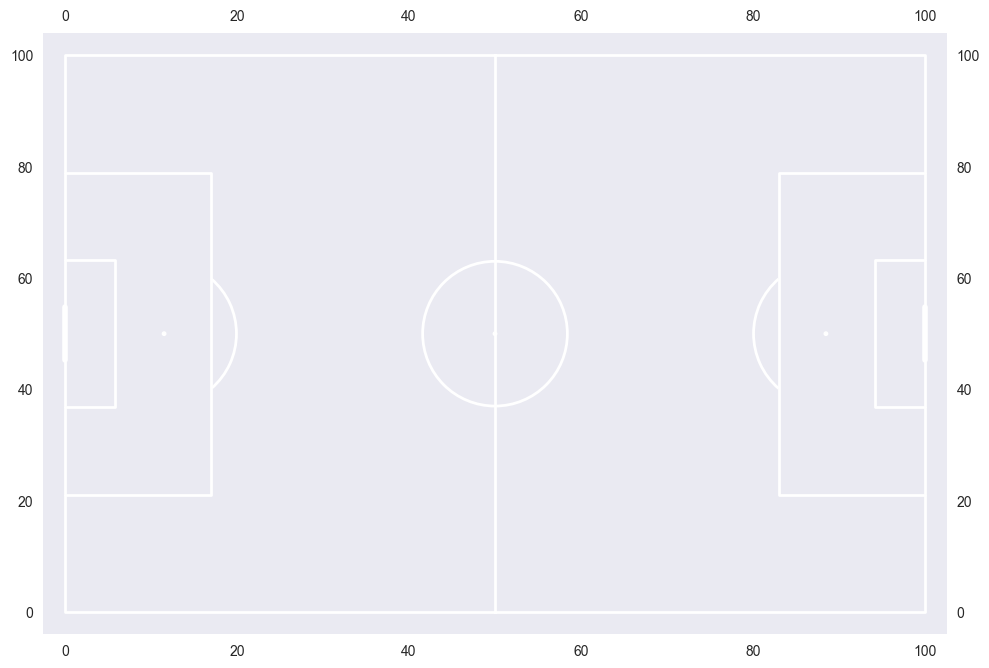

In [4]:


# 4) رسم زمین و لایه‌ها (فلش اگر pos0 و pos1 داشت؛ نقطه اگر تک‌نقطه)

# pitch = Pitch(pitch_type='opta', line_color='black')
pitch=Pitch(pitch_type='opta',  # example plotting a tracab pitch
              pitch_length=105, pitch_width=68,
              axis=False, label=True)
fig, ax = pitch.draw(figsize=(10, 7))
colors = {
    "passes": "orange",
    "Corners": "blue",
    "Clearances ": "green"
}

def draw_layer(df, label):
    # posOrder=0 به‌عنوان مبدا و posOrder=1 مقصد
    # اگر pos1 موجود بود، فلش؛ وگرنه دایره‌ی کوچک در pos0
    for _, r in df.iterrows():
        x0, y0, x1, y1 = r['pos0x'], r['pos0y'], r['pos1x'], r['pos1y']
        if pd.notna(x0) and pd.notna(y0) and pd.notna(x1) and pd.notna(y1):
            pitch.arrows(x0, y0, x1, y1, ax=ax, width=1.5, headwidth=4, headlength=4, label=label)
        elif pd.notna(x0) and pd.notna(y0):
            pitch.scatter([x0], [y0], ax=ax, s=10, label=label)

def in_zone(x, zone):
    """بررسی اینکه مختصات x در کدام ناحیه زمین قرار دارد"""
    if pd.isna(x):
        return False
    if zone == 0:
        return 0 <= x < 26.25
    elif zone == 1:
        return 26.25 <= x < 52.5
    elif zone == 2:
        return 52.5 <= x < 78.75
    elif zone == 3:
        return 78.75 <= x <= 105
    else:
        return True
# برای جلوگیری از تکرار لیبل در legend
def draw_unique(df, label, zone=None, color=None):
    """رسم پیکان‌ها یا نقاط با فیلتر ناحیه"""
    if df.empty:
        return
    first = True
    for _, r in df.iterrows():
        x0, y0, x1, y1 = r['pos0x'], r['pos0y'], r['pos1x'], r['pos1y']

        # اگر ناحیه مشخص شده باشد، فقط موارد مربوط به آن ناحیه نمایش داده شود
        if zone is not None:
            if not in_zone(x1 if pd.notna(x1) else x0, zone):
                continue

        lbl = label if first else None
        first = False

        if pd.notna(x0) and pd.notna(y0) and pd.notna(x1) and pd.notna(y1):
            pitch.arrows(x0, y0, x1, y1, ax=ax,color=color,
                         width=1.5, headwidth=4, headlength=4, label=lbl)
        elif pd.notna(x0) and pd.notna(y0):
            pitch.scatter([x0], [y0], ax=ax, s=10, color=color,label=lbl)

draw_unique(df_assist,          "Assists (both teams)",color="red")
draw_unique(df_simple_home,     "Simple passes (Home)", color=colors["passes"])
draw_unique(df_simple_home,     "Simple passes (Home)")
draw_unique(df_high_home,       "High passes (Home)", zone=1)
# draw_unique(df_throw_away,      "Throw-ins (Away)")
draw_unique(df_corner_home,     "Corners (Home)")
# draw_unique(df_fk_shot_away,    "Free-kick (shots) Away")
# draw_unique(df_clear_home,      "Clearances (Home)")

# عنوان با Diff ها از per_match_1.csv
title = (f"Match {MATCH_ID} │ assists_diff={assists_diff} │ high_passes_diff={high_passes_diff}\n"
         f"Layers: Assists, SimplePasses(Home), HighPasses(Home), Throw-ins(Away), Corners(Home), "
         f"FK Shots(Away), Clearances(Home)   (arrows: posOrder 0→1)")
ax.set_title(title)

# راهنمای کوچک
handles, labels = ax.get_legend_handles_labels()
if labels:
    # حذف لیبل‌های تکراری
    seen = set()
    uniq = [(h, l) for h, l in zip(handles, labels) if not (l in seen or seen.add(l))]
    ax.legend(*zip(*uniq), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

In [7]:
df_simple_home.head()

NameError: name 'df_simple_home' is not defined

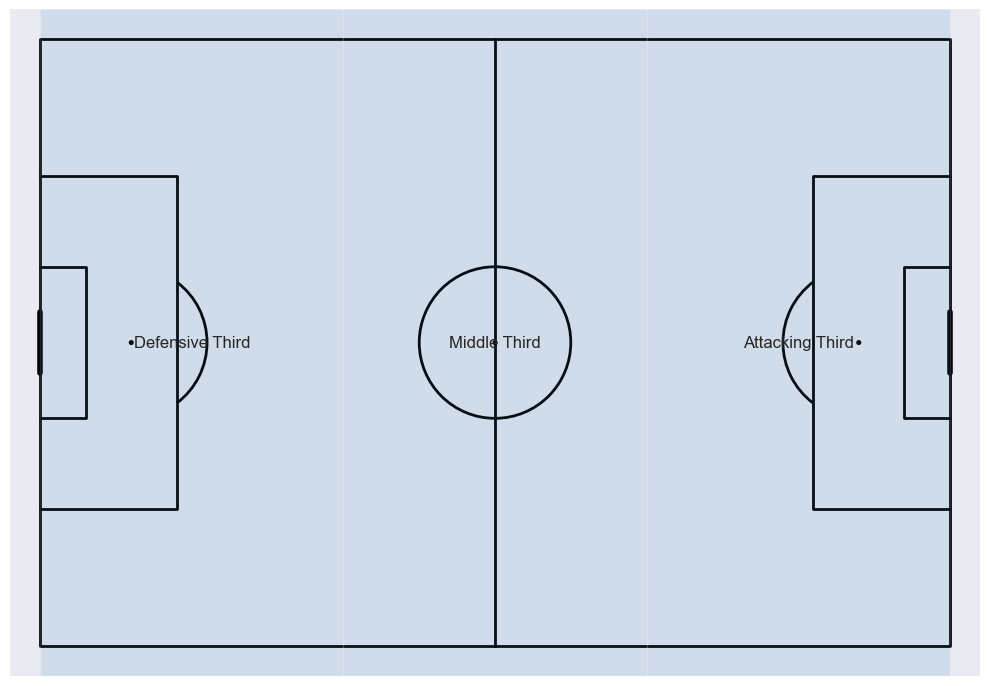

In [6]:
# %% تقسیم زمین به 3 بخش (یک‌سوم‌ها)
import matplotlib.pyplot as plt
from mplsoccer import Pitch

# اگر زمین‌تان از نوع دیگری است، pitch_type را تغییر دهید (مثلاً 'opta' یا 'uefa')
pitch = Pitch(pitch_type='statsbomb', line_color='black')
fig, ax = pitch.draw(figsize=(10, 7))

# مرزهای یک‌سوم‌ها (برای StatsBomb: طول 0..120)
third_1_end = 40
third_2_end = 80
third_3_end = 120

# هایلایت هر یک‌سوم با نوارهای عمودی نیمه‌شفاف
ax.axvspan(0, third_1_end,  alpha=0.12)   # یک‌سوم دفاعی
ax.axvspan(third_1_end, third_2_end, alpha=0.12)   # یک‌سوم میانی
ax.axvspan(third_2_end, third_3_end, alpha=0.12)   # یک‌سوم هجومی

# برچسب‌ها در مرکز هر ناحیه
y_center = 40  # برای StatsBomb عرض 80 => مرکز 40
ax.text(third_1_end/2, y_center, "Defensive Third", ha='center', va='center', fontsize=12)
ax.text((third_1_end+third_2_end)/2, y_center, "Middle Third", ha='center', va='center', fontsize=12)
ax.text((third_2_end+third_3_end)/2, y_center, "Attacking Third", ha='center', va='center', fontsize=12)

plt.tight_layout()
plt.show()

In [5]:
# %% فقط نمایش High Pass در منطقه Attacking Third
# %% High Passes فقط در Attacking Third با عیب‌یابی خودکار
import os, sqlite3, pandas as pd
import matplotlib.pyplot as plt
from mplsoccer import Pitch

DB_PATH = "/Users/milad/Desktop/Rulex/football_v2.db"
CSV_PATH = "/Users/milad/Desktop/Rulex/per_match_1.csv"

def die(msg):
    raise SystemExit("\n[ERROR] " + msg)

# 0) بررسی فایل‌ها
if not os.path.exists(DB_PATH):
    die(f"/Users/milad/Desktop/Rulex/per_match_1.csv")
if not os.path.exists(CSV_PATH):
    die("/Users/milad/Desktop/Rulex/per_match_1.csv")

# 1) خواندن یک match برای تست
df_match = pd.read_csv("/Users/milad/Desktop/Rulex/per_match_1.csv")
if "ç" not in df_match.columns:
    die("per_match_1.csv")
MATCH_ID = int(df_match["matchId"].iloc[0])

# 2) اتصال به DB و کشف نام ستون‌ها/مقادیر
conn = sqlite3.connect(DB_PATH)
cur = conn.cursor()

# جدول‌ها
tabs = [r[0] for r in cur.execute("SELECT name FROM sqlite_master WHERE type='table'")]
for t in ("events","event_positions"):
    if t not in tabs:
        die(f"no such table: {t}  (نام جدول در DB شما متفاوت است)")

# ستون‌های جدول events
ev_cols = [r[1] for r in cur.execute("PRAGMA table_info(events)")]
pos_cols = [r[1] for r in cur.execute("PRAGMA table_info(event_positions)")]

# نگاشت منعطف نام ستون‌ها
COL_EVENT_ID = "eventId" if "eventId" in ev_cols else ("id" if "id" in ev_cols else None)
COL_MATCH_ID = "matchId" if "matchId" in ev_cols else None
COL_TEAM_ID  = "teamId"  if "teamId"  in ev_cols else None
COL_ENAME    = "eventName" if "eventName" in ev_cols else ("event_name" if "event_name" in ev_cols else None)
COL_SUBE     = "subEventName" if "subEventName" in ev_cols else ("sub_event_name" if "sub_event_name" in ev_cols else None)

if not all([COL_EVENT_ID, COL_MATCH_ID, COL_TEAM_ID, COL_ENAME, COL_SUBE]):
    die(f"ستون‌های موردنیاز در events کامل نیستند: {ev_cols}")

# ستون‌های جدول event_positions
COL_P_EVENT  = "eventId" if "eventId" in pos_cols else ("event_id" if "event_id" in pos_cols else None)
COL_POSORDER = "posOrder" if "posOrder" in pos_cols else ("pos_order" if "pos_order" in pos_cols else None)
COL_X        = "x" if "x" in pos_cols else None
COL_Y        = "y" if "y" in pos_cols else None
if not all([COL_P_EVENT, COL_POSORDER, COL_X, COL_Y]):
    die(f"ستون‌های موردنیاز در event_positions کامل نیستند: {pos_cols}")

# کشف مقدار صحیح «High pass» در دیتای شما
distinct_sub = [r[0] for r in cur.execute(f"SELECT DISTINCT {COL_SUBE} FROM events")]
# نمونه‌های رایج: 'High pass', 'Long pass', 'Launch', ...
candidates = [s for s in distinct_sub if s and ("High" in s or "Long" in s)]
SUB_HIGH = None
for c in candidates:
    # چک می‌کنیم واقعاً Pass است
    cur.execute(f"""
        SELECT COUNT(*)
        FROM events
        WHERE {COL_MATCH_ID}=? AND {COL_ENAME}='Pass' AND {COL_SUBE}=?
    """, (MATCH_ID, c))
    if cur.fetchone()[0] > 0:
        SUB_HIGH = c
        break

if SUB_HIGH is None:
    # آخرین تیر: جستجو با LIKE
    cur.execute(f"""
        SELECT COUNT(*)
        FROM events
        WHERE {COL_MATCH_ID}=? AND {COL_ENAME}='Pass' AND {COL_SUBE} LIKE '%High%pass%'
    """, (MATCH_ID,))
    if cur.fetchone()[0] > 0:
        SUB_HIGH = "%LIKE%"
    else:
        die("هیچ زیررویدادی برای پاس بلند پیدا نشد. مقادیر subEventName را بررسی کن:\n" + str(sorted(set(distinct_sub))[:30]))

# 3) واکشی پاس‌های بلند و فیلتر به posOrder=0 و x>80 (attacking third)
if SUB_HIGH == "%LIKE%":
    sql = f"""
    SELECT e.{COL_EVENT_ID} AS eid, e.{COL_TEAM_ID} AS tid, p.{COL_POSORDER} AS po, p.{COL_X} AS x, p.{COL_Y} AS y
    FROM events e
    JOIN event_positions p ON e.{COL_EVENT_ID}=p.{COL_P_EVENT}
    WHERE e.{COL_MATCH_ID}=? AND e.{COL_ENAME}='Pass' AND e.{COL_SUBE} LIKE '%High%pass%'
    """
    params = (MATCH_ID,)
else:
    sql = f"""
    SELECT e.{COL_EVENT_ID} AS eid, e.{COL_TEAM_ID} AS tid, p.{COL_POSORDER} AS po, p.{COL_X} AS x, p.{COL_Y} AS y
    FROM events e
    JOIN event_positions p ON e.{COL_EVENT_ID}=p.{COL_P_EVENT}
    WHERE e.{COL_MATCH_ID}=? AND e.{COL_ENAME}='Pass' AND e.{COL_SUBE}=?
    """
    params = (MATCH_ID, SUB_HIGH)

df = pd.read_sql_query(sql, conn, params=params)
conn.close()

if df.empty:
    die("هیچ پاس بلندی برای این matchId پیدا نشد.")

# فقط شروع پاس (posOrder=0)
if df["po"].min() is None:
    die("ستون posOrder داده ندارد.")
df0 = df[df["po"]==0].copy()

# Attacking third برای StatsBomb: x>80
df_attack = df0[df0["x"]>80]

# 4) رسم
pitch = Pitch(pitch_type='statsbomb', line_color='black')
fig, ax = pitch.draw(figsize=(10,7))
ax.axvspan(80, 120, alpha=0.12)  # highlight attacking third

from math import isnan
xs = df_attack["x"].tolist()
ys = df_attack["y"].tolist()
# حذف NaN
xs = [x for x in xs if x==x]
ys = [y for y in ys if y==y]
pitch.scatter(xs, ys, ax=ax, s=20, label=f"High Pass ({SUB_HIGH if SUB_HIGH!='%LIKE%' else 'LIKE High%pass'})")

ax.text(100, 75, f"Total High Passes (Attacking Third): {len(xs)}", ha="center", fontsize=12)
ax.legend(loc="upper left", fontsize=9)
ax.set_title(f"High Passes in Attacking Third (matchId={MATCH_ID})", fontsize=14)
plt.tight_layout()
plt.show()

SystemExit: 
[ERROR] per_match_1.csv